In [ ]:
import pandas as pd

# 读取数据（加上完整路径）
df = pd.read_csv('/olist_orders_dataset.csv')

# 看前5行
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# 1. 数据基本信息
print("Dataset shape (rows, columns):", df.shape)
print("\nColumn data types:")
print("\nMissing values:")
print("Data types after conversion:")

数据形状（行数，列数）： (99441, 8)

各列数据类型：
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

缺失值：
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [ ]:
# 把所有日期列转成datetime格式
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

# 确认转换成功
print("转换后的数据类型：")
print(df[date_cols].dtypes)


转换后的数据类型：
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [8]:

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = df.groupby('order_month').size()
monthly_orders.columns = ['month', 'orders']

print(monthly_orders)

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64


In [10]:

delivered = df[df['order_status'] == 'delivered'].copy()

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] -
    delivered['order_purchase_timestamp']
).dt.days


print("平均配送天数：", delivered['delivery_days'].mean().round(1))
print("最快配送天数：", delivered['delivery_days'].min())
print("最慢配送天数：", delivered['delivery_days'].max())
print("中位数天数：", delivered['delivery_days'].median())

平均配送天数： 12.1
最快配送天数： 0.0
最慢配送天数： 209.0
中位数天数： 10.0


In [11]:

user_orders = df.groupby('customer_id').size().reset_index()
user_orders.columns = ['customer_id', '订单数']


total_users = len(user_orders)


repeat_users = user_orders[user_orders['订单数'] > 1]


repeat_rate = len(repeat_users) / total_users * 100

print(f"总用户数：{total_users:,}")
print(f"复购用户数：{len(repeat_users):,}")
print(f"复购率：{repeat_rate:.2f}%")
print(f"\n订单数分布：")
print(user_orders['订单数'].value_counts().head(10))

总用户数：99,441
复购用户数：0
复购率：0.00%

订单数分布：
订单数
1    99441
Name: count, dtype: int64


In [12]:

first_purchase = df.groupby('customer_id')['order_purchase_timestamp'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']
first_purchase['cohort'] = first_purchase['first_purchase_date'].dt.to_period('M')


df2 = df.merge(first_purchase[['customer_id', 'cohort']], on='customer_id')

df2['order_month'] = df2['order_purchase_timestamp'].dt.to_period('M')


df2['months_since_first'] = (
    df2['order_month'] - df2['cohort']
).apply(lambda x: x.n)

print(df2[['customer_id', 'cohort', 'order_month', 'months_since_first']].head(10))

                        customer_id   cohort order_month  months_since_first
0  9ef432eb6251297304e76186b10a928d  2017-10     2017-10                   0
1  b0830fb4747a6c6d20dea0b8c802d7ef  2018-07     2018-07                   0
2  41ce2a54c0b03bf3443c3d931a367089  2018-08     2018-08                   0
3  f88197465ea7920adcdbec7375364d82  2017-11     2017-11                   0
4  8ab97904e6daea8866dbdbc4fb7aad2c  2018-02     2018-02                   0
5  503740e9ca751ccdda7ba28e9ab8f608  2017-07     2017-07                   0
6  ed0271e0b7da060a393796590e7b737a  2017-04     2017-04                   0
7  9bdf08b4b3b52b5526ff42d37d47f222  2017-05     2017-05                   0
8  f54a9f0e6b351c431402b8461ea51999  2017-01     2017-01                   0
9  31ad1d1b63eb9962463f764d4e6e0c9d  2017-07     2017-07                   0


In [13]:

cohort_data = df2.groupby(['cohort', 'months_since_first'])['customer_id'].nunique().reset_index()
cohort_data.columns = ['cohort', 'months_since_first', 'users']


cohort_matrix = cohort_data.pivot_table(
    index='cohort',
    columns='months_since_first',
    values='users'
)


cohort_size = cohort_matrix[0]
retention_matrix = cohort_matrix.divide(cohort_size, axis=0).round(3)

print(retention_matrix.iloc[:8, :6])

months_since_first    0
cohort                 
2016-09             1.0
2016-10             1.0
2016-12             1.0
2017-01             1.0
2017-02             1.0
2017-03             1.0
2017-04             1.0
2017-05             1.0


In [16]:

monthly_orders = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
).size().reset_index()

monthly_orders.columns = ['月份', '订单量']

print(monthly_orders.head())
print(type(monthly_orders))

        月份   订单量
0  2016-09     4
1  2016-10   324
2  2016-12     1
3  2017-01   800
4  2017-02  1780
<class 'pandas.core.frame.DataFrame'>


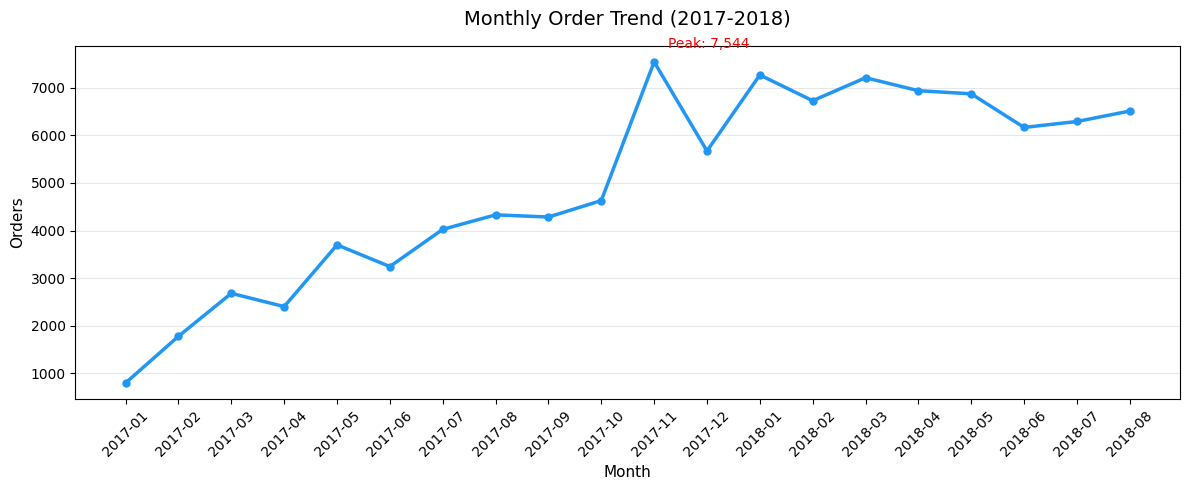

In [17]:
import matplotlib.pyplot as plt

plot_data = monthly_orders[
    (monthly_orders['月份'].astype(str) >= '2017-01') &
    (monthly_orders['月份'].astype(str) <= '2018-08')
].copy()


fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    plot_data['月份'].astype(str),
    plot_data['订单量'],
    color='#2196F3',
    linewidth=2.5,
    marker='o',
    markersize=5
)


max_idx = plot_data['订单量'].idxmax()
max_row = plot_data.loc[max_idx]
ax.annotate(
    f"Peak: {int(max_row['订单量']):,}",
    xy=(str(max_row['月份']), max_row['订单量']),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    color='red'
)

ax.set_title('Monthly Order Trend (2017-2018)', fontsize=14, pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Orders', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_orders.png', dpi=150)
plt.show()

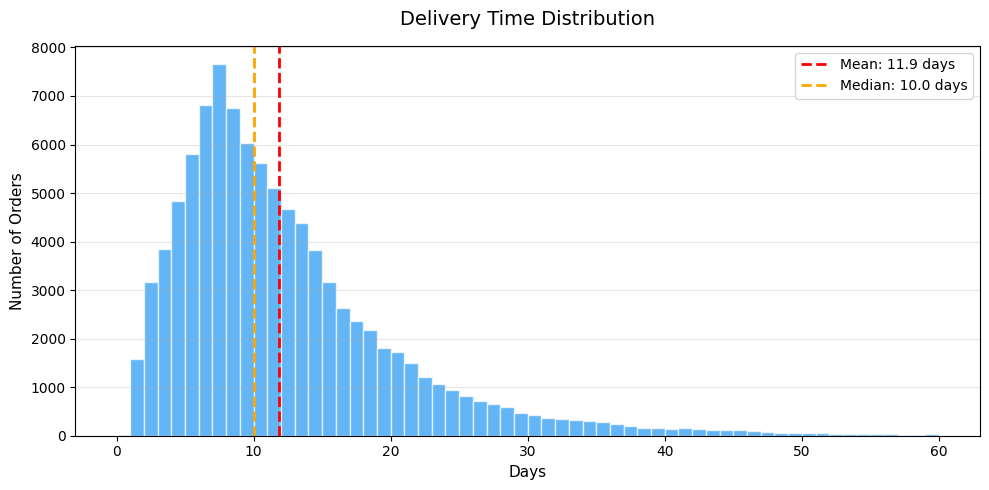

In [18]:
import matplotlib.pyplot as plt


clean_delivery = delivered[
    (delivered['delivery_days'] >= 0) &
    (delivered['delivery_days'] <= 60)
]['delivery_days']

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(clean_delivery, bins=60, color='#2196F3', alpha=0.7, edgecolor='white')


ax.axvline(clean_delivery.mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {clean_delivery.mean():.1f} days')
ax.axvline(clean_delivery.median(), color='orange', linestyle='--',
           linewidth=2, label=f'Median: {clean_delivery.median():.1f} days')

ax.set_title('Delivery Time Distribution', fontsize=14, pad=15)
ax.set_xlabel('Days', fontsize=11)
ax.set_ylabel('Number of Orders', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('delivery_distribution.png', dpi=150)
plt.show()